In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


1. Abnormal
2. Artifact_high_gain
3. Artifact_phase_shift
4. Normal
x_train shape: (3227, 100), y_train shape: (3227, 4)
x_test shape: (570, 100), y_test shape: (570, 4)
(tensor([  3.5489,   5.9004,  14.6586,  24.7298,  31.8239,  36.7951,  40.5660,
         48.3114,  64.9187,  81.6538,  92.9426, 104.0555, 115.5077, 126.7293,
        140.4836, 155.4559, 163.6910, 162.4535, 160.5930, 162.6625, 164.2247,
        160.8127, 153.5975, 148.5576, 143.8335, 135.9976, 130.4624, 126.2709,
        122.3938, 119.9526, 111.9361, 100.7387,  91.9943,  83.7536,  76.3615,
         68.7046,  61.4273,  58.3572,  55.6512,  48.0372,  40.1903,  34.6219,
         28.8192,  26.1662,  23.9494,  17.5491,  11.0190,   4.0519,  -3.5047,
         -1.6174,  13.0976,  17.1931,  22.2285,  28.0024,  34.3806,  41.6987,
         50.0239,  59.1547,  69.0241,  79.6320,  90.6428, 101.7878, 112.9328,
        123.9435, 134.3500, 144.1523, 153.0146, 160.6684, 167.1137, 171.9477,
        175.3046, 176.9831, 177.1174, 175.8417, 1

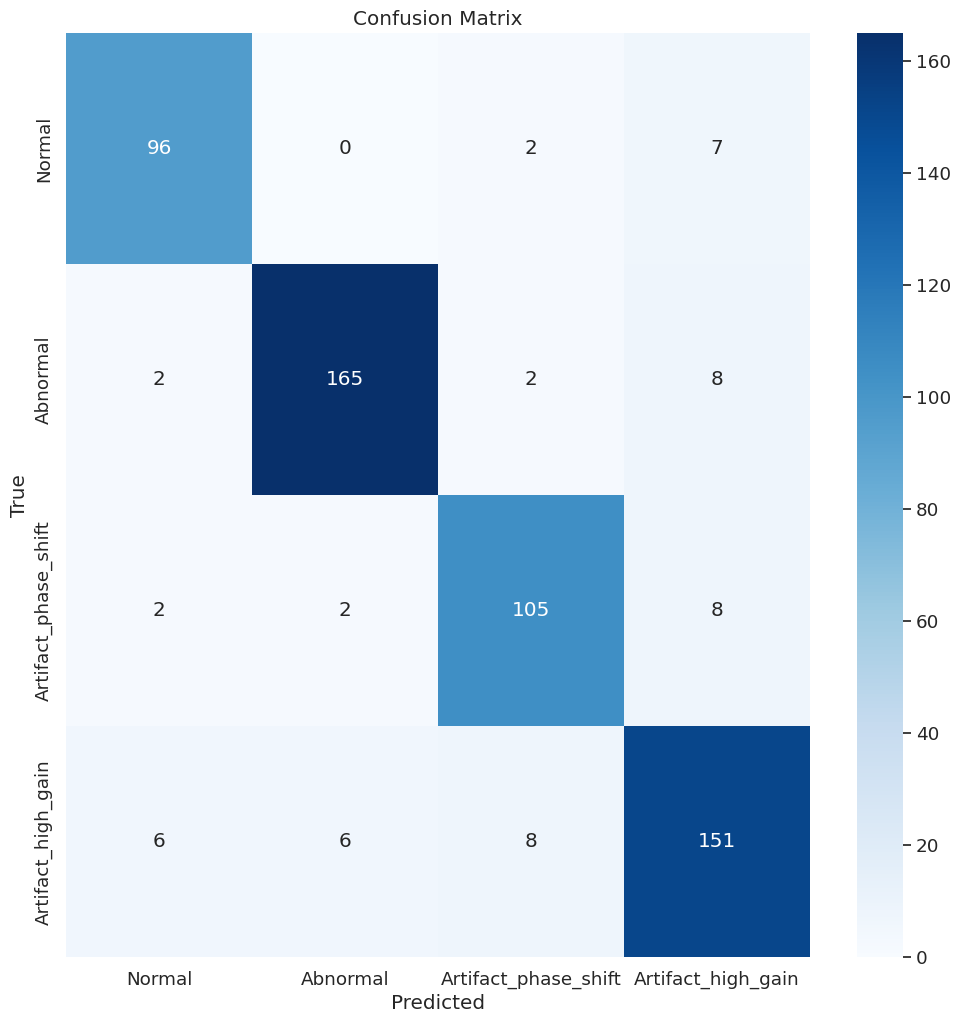

                      precision    recall  f1-score   support

              Normal       0.91      0.91      0.91       105
            Abnormal       0.95      0.93      0.94       177
Artifact_phase_shift       0.90      0.90      0.90       117
  Artifact_high_gain       0.87      0.88      0.88       171

            accuracy                           0.91       570
           macro avg       0.91      0.91      0.91       570
        weighted avg       0.91      0.91      0.91       570



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix

LABELS = ['Normal', 'Abnormal', 'Artifact_phase_shift', 'Artifact_high_gain']

file_data = "/content/drive/My Drive/_left_ready.csv"
file_labels = "/content/drive/My Drive/_labels_ready_new.csv"

BATCH_SIZE = 128
NUM_EPOCH = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CustomDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]



def read_data(data_filename, label_filename):
    features = 2
    try:
        df = pd.read_csv(data_filename)
        df_labels = pd.read_csv(label_filename)
    except FileNotFoundError:
        print("File not found. Please check the file path.")
        return None

    impulse = []
    data = np.asarray(df)
    label = np.asarray(df_labels)

    # Multi-label binarization
    mlb = MultiLabelBinarizer()
    classes = mlb.fit_transform(label)
    num_of_subclasses = len(mlb.classes_)
    for (i, label) in enumerate(mlb.classes_):
        print("{}. {}".format(i + 1, label))

    # Preprocessing
    input_size = data.shape[1] - 125
    shape = input_size * features
    eye = data[range(0, data.shape[0], 2)]
    head = data[range(1, data.shape[0], 2)]

    eye50 = [item3[25:75] for item3 in eye]
    head50 = [item4[25:75] for item4 in head]

    for i in range(len(eye)):
        impulseEye = np.asarray(eye50[i])
        impulseHead = np.asarray(head50[i])
        impulse.append([impulseEye, impulseHead])

    segments = np.asarray(impulse, dtype=np.float32).reshape(-1, input_size, features)
    segments = segments.reshape(segments.shape[0], shape)

    return segments, classes, shape, input_size, num_of_subclasses, mlb

class ConvNet(nn.Module):
    def __init__(self, input_shape, class_num):
        super(ConvNet, self).__init__()

        self.input_shape = input_shape

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=50, kernel_size=5)
        self.conv2 = nn.Conv1d(in_channels=50, out_channels=50, kernel_size=5)
        self.conv3 = nn.Conv1d(in_channels=50, out_channels=100, kernel_size=5)
        self.conv4 = nn.Conv1d(in_channels=100, out_channels=100, kernel_size=5)
        self.pool = nn.MaxPool1d(kernel_size=3)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(100, class_num)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.global_pool(x).squeeze(-1)
        x = self.dropout(x)
        x = self.fc(x)

        return x



def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    model.to(DEVICE)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {running_loss / len(train_loader):.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == torch.argmax(labels, dim=1)).sum().item()
                total += labels.size(0)
        val_acc = correct / total
        print(f"Validation Loss: {val_loss / len(val_loader):.4f}, Validation Accuracy: {val_acc:.4f}")

def plot_confusion_matrix(true_labels, pred_labels):
    sns.set(font_scale=1.2)
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


segments, labels, input_shape, time_period, class_num, mlb = read_data(file_data, file_labels)
if segments is not None:
    x_train, x_test, y_train, y_test = train_test_split(segments, labels, test_size=0.15, random_state=42)
    print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
    print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


    sample_dataset = CustomDataset(x_train[:10], y_train[:10])
    print(sample_dataset[0])  #  return (data, label)




    train_dataset = CustomDataset(x_train, y_train)
    test_dataset = CustomDataset(x_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model = ConvNet(input_shape, class_num)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCH)

    # Evaluate model
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(torch.argmax(labels, dim=1).cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    plot_confusion_matrix(y_true, y_pred)
    print(classification_report(y_true, y_pred, target_names=LABELS))

# Feature extraction RF

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


def extract_features(data):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()

        peak_height = np.max(signal)
        peak_width = np.argmax(signal) - np.argmin(signal)
        max_velocity_slope = np.gradient(signal)[np.argmax(np.gradient(signal))]

        mean = np.mean(signal)
        variance = np.var(signal)
        skewness = pd.Series(signal).skew() # Коэффициент асимметрии
        kurtosis = pd.Series(signal).kurtosis() # Коэффициент эксцесса (хвостиковости)

        features.append([peak_height, peak_width, max_velocity_slope, mean, variance, skewness, kurtosis])
    return np.array(features)


file_data = "/content/drive/My Drive/_left_ready.csv"
file_labels = "/content/drive/My Drive/_labels_ready_new.csv"

df = pd.read_csv(file_data)
df_labels = pd.read_csv(file_labels)

data = np.asarray(df)
labels = np.asarray(df_labels)


min_samples = min(len(data), len(labels))
data = data[:min_samples]
labels = labels[:min_samples]
labels = labels.ravel()

features = extract_features(data)


print("Features shape:", features.shape)
print("Labels shape:", labels.shape)


X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Features shape: (3797, 7)
Labels shape: (3797,)
Accuracy: 0.4263157894736842
                      precision    recall  f1-score   support

              Normal       0.33      0.34      0.33       105
            Abnormal       0.46      0.50      0.48       177
Artifact_phase_shift       0.39      0.38      0.38       117
  Artifact_high_gain       0.48      0.44      0.46       171

            accuracy                           0.43       570
           macro avg       0.41      0.41      0.41       570
        weighted avg       0.43      0.43      0.43       570



# SVM

In [ ]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.41228070175438597
                      precision    recall  f1-score   support

              Normal       0.30      0.06      0.10       105
            Abnormal       0.40      0.68      0.51       177
Artifact_phase_shift       0.45      0.13      0.20       117
  Artifact_high_gain       0.43      0.54      0.48       171

            accuracy                           0.41       570
           macro avg       0.40      0.35      0.32       570
        weighted avg       0.40      0.41      0.36       570



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 5], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear', 'poly']}
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
clf = SVC(kernel='rbf', C=5, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.3929824561403509
                      precision    recall  f1-score   support

              Normal       0.32      0.17      0.22       105
            Abnormal       0.39      0.56      0.46       177
Artifact_phase_shift       0.39      0.17      0.24       117
  Artifact_high_gain       0.42      0.50      0.46       171

            accuracy                           0.39       570
           macro avg       0.38      0.35      0.34       570
        weighted avg       0.39      0.39      0.37       570



# SVM signal features + Fourier

In [ ]:
def extract_features_Forier(data):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()

        peak_height = np.max(signal)
        peak_width = np.argmax(signal) - np.argmin(signal)
        max_velocity_slope = np.gradient(signal)[np.argmax(np.gradient(signal))]
        mean = np.mean(signal)
        variance = np.var(signal)
        skewness = pd.Series(signal).skew()
        kurtosis = pd.Series(signal).kurtosis()

        fft_values = np.fft.fft(signal)
        magnitude_spectrum = np.abs(fft_values)
        dominant_frequency = np.argmax(magnitude_spectrum)
        mean_freq = np.mean(magnitude_spectrum)
        var_freq = np.var(magnitude_spectrum)

        features.append([
            peak_height, peak_width, max_velocity_slope, mean, variance, skewness, kurtosis,
            dominant_frequency, mean_freq, var_freq
        ])
    return np.array(features)


features = extract_features_Forier(data)


print("Features shape:", features.shape)
print("Labels shape:", labels.shape)


X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Features shape: (3797, 10)
Labels shape: (3797,)
Accuracy: 0.4070175438596491
                      precision    recall  f1-score   support

              Normal       0.33      0.06      0.10       105
            Abnormal       0.41      0.68      0.51       177
Artifact_phase_shift       0.44      0.14      0.21       117
  Artifact_high_gain       0.40      0.52      0.46       171

            accuracy                           0.41       570
           macro avg       0.40      0.35      0.32       570
        weighted avg       0.40      0.41      0.36       570



# Random forest signal features + Fourier

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.45614035087719296
                      precision    recall  f1-score   support

              Normal       0.39      0.41      0.40       105
            Abnormal       0.51      0.55      0.53       177
Artifact_phase_shift       0.37      0.31      0.34       117
  Artifact_high_gain       0.49      0.49      0.49       171

            accuracy                           0.46       570
           macro avg       0.44      0.44      0.44       570
        weighted avg       0.45      0.46      0.45       570



In [ ]:
def extract_features_Forier_only(data):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()
        fft_values = np.fft.fft(signal)
        magnitude_spectrum = np.abs(fft_values)
        dominant_frequency = np.argmax(magnitude_spectrum)
        mean_freq = np.mean(magnitude_spectrum)
        var_freq = np.var(magnitude_spectrum)

        features.append([dominant_frequency, mean_freq, var_freq])
    return np.array(features)


features = extract_features_Forier_only(data)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.4017543859649123
                      precision    recall  f1-score   support

              Normal       0.40      0.04      0.07       105
            Abnormal       0.41      0.68      0.51       177
Artifact_phase_shift       0.39      0.11      0.17       117
  Artifact_high_gain       0.39      0.54      0.45       171

            accuracy                           0.40       570
           macro avg       0.40      0.34      0.30       570
        weighted avg       0.40      0.40      0.34       570



In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.39649122807017545
                      precision    recall  f1-score   support

              Normal       0.32      0.36      0.34       105
            Abnormal       0.44      0.46      0.45       177
Artifact_phase_shift       0.34      0.25      0.29       117
  Artifact_high_gain       0.43      0.45      0.44       171

            accuracy                           0.40       570
           macro avg       0.38      0.38      0.38       570
        weighted avg       0.39      0.40      0.39       570



# Wavelet transform

In [ ]:
pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.9 MB/s eta 0:00:00


In [ ]:
import pywt

def extract_features_wavelet(data, wavelet='db1', level=3):
    features = []
    for signal in data:
        signal = np.asarray(signal).flatten()

        peak_height = np.max(signal)
        peak_width = np.argmax(signal) - np.argmin(signal)
        max_velocity_slope = np.gradient(signal)[np.argmax(np.gradient(signal))]
        mean = np.mean(signal)
        variance = np.var(signal)
        skewness = pd.Series(signal).skew()
        kurtosis = pd.Series(signal).kurtosis()


        coeffs = pywt.wavedec(signal, wavelet, level=level)
        wavelet_features = []
        for i, coeff in enumerate(coeffs):
            if i == 0:
                wavelet_features.append(np.mean(coeff))
                wavelet_features.append(np.var(coeff))
            else:
                wavelet_features.append(np.mean(coeff))
                wavelet_features.append(np.var(coeff))
                wavelet_features.append(np.sum(np.square(coeff)))

        features.append([
            peak_height, peak_width, max_velocity_slope, mean, variance, skewness, kurtosis,
            *wavelet_features
        ])
    return np.array(features)



features = extract_features_wavelet(data, wavelet='coif1', level=3)

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.4245614035087719
                      precision    recall  f1-score   support

              Normal       0.50      0.11      0.19       105
            Abnormal       0.43      0.71      0.54       177
Artifact_phase_shift       0.41      0.12      0.19       117
  Artifact_high_gain       0.41      0.53      0.46       171

            accuracy                           0.42       570
           macro avg       0.44      0.37      0.34       570
        weighted avg       0.43      0.42      0.38       570



In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=LABELS))

Accuracy: 0.47368421052631576
                      precision    recall  f1-score   support

              Normal       0.42      0.35      0.38       105
            Abnormal       0.51      0.58      0.54       177
Artifact_phase_shift       0.42      0.33      0.37       117
  Artifact_high_gain       0.48      0.54      0.51       171

            accuracy                           0.47       570
           macro avg       0.46      0.45      0.45       570
        weighted avg       0.47      0.47      0.47       570



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Impulse dataset shape: (7595, 175)
Labels dataset shape: (3797, 1)
Eye data shape: (3797, 175)
Head data shape: (3797, 175)
               Labels       Predicted Class  Confidence (%)
0  Artifact_high_gain  Artifact_phase_shift       64.752388
1  Artifact_high_gain              Abnormal      150.686765
2  Artifact_high_gain  Artifact_phase_shift       75.807285
3  Artifact_high_gain  Artifact_phase_shift      123.928690
4  Artifact_high_gain  Artifact_phase_shift      200.406408


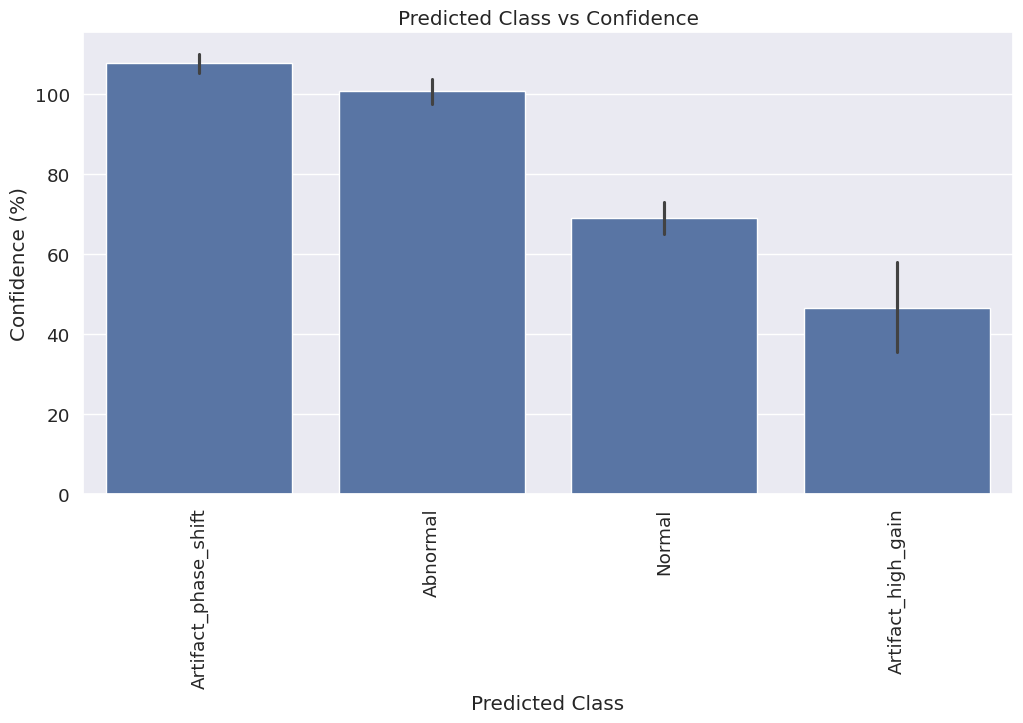

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from google.colab import drive


drive.mount('/content/drive')


impulse_path = '/content/drive/My Drive/_left_ready.csv'
labels_path = '/content/drive/My Drive/_labels_ready_new.csv'
model_path = '/content/drive/My Drive/final_model.pth'

# Load impulse data and labels
impulse_data = pd.read_csv(impulse_path, header=None)
labels = pd.read_csv(labels_path)

print("Impulse dataset shape:", impulse_data.shape)
print("Labels dataset shape:", labels.shape)

# Split into EYE and HEAD data
eye_data = impulse_data.iloc[::2].reset_index(drop=True)  # Odd rows for EYE
head_data = impulse_data.iloc[1::2].reset_index(drop=True)  # Even rows for HEAD

# Align lengths
if eye_data.shape[0] > head_data.shape[0]:
    eye_data = eye_data[:-1]


print("Eye data shape:", eye_data.shape)
print("Head data shape:", head_data.shape)


input_size = 50  # 50 time steps
features = 2  # Eye and Head combined
shape = input_size * features  # Total features is 100

# Process data for prediction
segments = []
for i in range(len(eye_data)):
    combined_segment = np.concatenate((eye_data.iloc[i].values[:50], head_data.iloc[i].values[:50]), axis=0)
    segments.append(combined_segment.flatten())  # Reshape to (100,)

segments = np.array(segments, dtype=np.float32)


class ConvNet(nn.Module):
    def __init__(self, input_shape, class_num):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv1d(1, 50, 5)
        self.conv2 = nn.Conv1d(50, 50, 5)
        self.pool = nn.MaxPool1d(3)
        self.conv3 = nn.Conv1d(50, 100, 5)
        self.conv4 = nn.Conv1d(100, 100, 5)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(100, class_num)

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch_size, 1, input_shape)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.global_pool(x).squeeze(-1)  # Flatten
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Define the number of classes
LABELS = ['Normal', 'Abnormal', 'Artifact_phase_shift', 'Artifact_high_gain']
mlb = MultiLabelBinarizer(classes=LABELS)
mlb.fit([LABELS])
class_num = len(LABELS)



# Predict with the model
segments_tensor = torch.tensor(segments)  # Convert to PyTorch tensor
y_pred = model(segments_tensor).detach().numpy()


predictions = []
for prediction in y_pred:
    top_idx = np.argmax(prediction)  # Get the index of the highest confidence
    class_name = mlb.classes_[top_idx]  # Get the class name
    confidence = prediction[top_idx] * 100  # Convert to a percent
    predictions.append((class_name, confidence))


predicted_classes = [pred[0] for pred in predictions]
confidence_scores = [pred[1] for pred in predictions]


labels["Predicted Class"] = predicted_classes
labels["Confidence (%)"] = confidence_scores


output_csv_path = "/content/drive/My Drive/predictions_output.csv"
labels.to_csv(output_csv_path, index=False)



print(labels.head())


plt.figure(figsize=(12, 6))
sns.barplot(x=predicted_classes, y=confidence_scores)
plt.title('Predicted Class vs Confidence')
plt.xlabel('Predicted Class')
plt.ylabel('Confidence (%)')
plt.xticks(rotation=90)
plt.show()


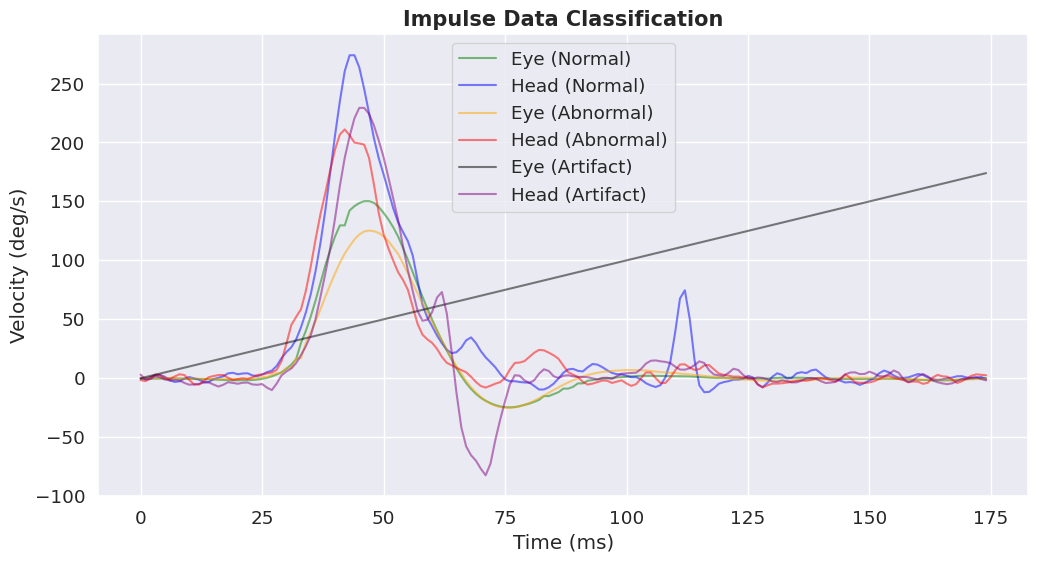

In [ ]:
import matplotlib.pyplot as plt

# Number of samples to plot per class
max_samples = 1

# Limit the number of indices for each class to max_samples
normal_idx = labels[labels["Predicted Class"] == "Normal"].index[:max_samples]
abnormal_idx = labels[labels["Predicted Class"] == "Abnormal"].index[:max_samples]
artifact_idx = labels[labels["Predicted Class"] == "Artifact_phase_shift"].index[:max_samples]

plt.figure(figsize=(12, 6))
plt.title("Impulse Data Classification", fontsize=15, fontweight="bold")
plt.xlabel("Time (ms)")
plt.ylabel("Velocity (deg/s)")
plt.grid(True)

# Plot normal impulses
for i in normal_idx:
    plt.plot(eye_data.iloc[i], label="Eye (Normal)", color="green", linestyle="solid", alpha=0.5)
    plt.plot(head_data.iloc[i], label="Head (Normal)", color="blue", linestyle="solid", alpha=0.5)

# Plot abnormal impulses
for i in abnormal_idx:
    plt.plot(eye_data.iloc[i], label="Eye (Abnormal)", color="orange", linestyle="solid", alpha=0.5)
    plt.plot(head_data.iloc[i], label="Head (Abnormal)", color="red", linestyle="solid", alpha=0.5)

# Plot artifacts
for i in artifact_idx:
    plt.plot(eye_data.iloc[i], label="Eye (Artifact)", color="black", linestyle="solid", alpha=0.5)
    plt.plot(head_data.iloc[i], label="Head (Artifact)", color="purple", linestyle="solid", alpha=0.5)

plt.legend()
plt.show()